In [67]:

import sys
from pathlib import Path
from loguru import logger
# Add the parent directory (core) to the Python path
notebook_dir = Path().resolve()
print(notebook_dir)
core_dir = notebook_dir.parent
if str(core_dir) not in sys.path:
    sys.path.insert(0, str(core_dir))

from Data.fyers_data_final import FyersDataScanner

/home/sham/Desktop/TradingAPP/TradingApp/core/analysis


In [76]:
scanner = FyersDataScanner()
scanner.start_date ='2025-12-01 16:15:00'
scanner.end_date = '2025-12-13 16:15:00'
# scanner.symbol = 'NSE:BANKNIFTY25DEC59200PE'
scanner.symbol = 'BSE:SENSEX25D1884800PE'
scanner.resolution = '5S'
d = scanner.get_data()

2025-12-16 03:22:59.164 | INFO     | Data.fyers_data_final:get_data:21 - Getting data for BSE:SENSEX25D1884800PE from 2025-12-01 16:15:00 to 2025-12-13 16:15:00 
2025-12-16 03:22:59.165 | INFO     | Data.fyers_data_final:get_data:22 - Resolution: 5S
2025-12-16 03:22:59.165 | INFO     | Data.DATA_SOURCE:get_data:66 - Cache name: fyers_cache_BSE:SENSEX25D1884800PE_1764605700_1765642500_5S
2025-12-16 03:22:59.691 | ERROR    | Data.DATA_SOURCE:get_data:101 - Error in fetching data: 6 columns passed, passed data had 7 columns
2025-12-16 03:23:00.701 | INFO     | Data.fyers_data_final:get_data:36 - Data: 27649 rows


In [77]:
df = d[['datetime','Open','Close','High','Low','Vol','TradeVol']].copy()
# timestamp,open,high,low,close,volume
df.rename(columns={'Vol':'volume','datetime':'timestamp','Open':'open','Close':'close','High':'high','Low':'low','TradeVol':'trade_volume'},inplace=True)


In [78]:
df

,timestamp,open,close,high,low,volume,trade_volume
0,12-04-2025 14:29:50,359.75,359.75,359.75,359.75,0,20
1,12-04-2025 14:29:55,359.75,359.75,359.75,359.75,0,0
2,12-04-2025 14:30:00,359.75,359.75,359.75,359.75,0,0
3,12-04-2025 14:30:05,359.75,359.75,359.75,359.75,0,0
4,12-04-2025 14:30:10,359.75,359.75,359.75,359.75,0,0
...,...,...,...,...,...,...,...
27644,12-12-2025 15:29:35,155.70,156.30,156.55,155.70,290480,2860
27645,12-12-2025 15:29:40,156.30,157.80,158.00,156.30,290480,3560
27646,12-12-2025 15:29:45,157.70,158.30,158.30,157.00,290480,600
27647,12-12-2025 15:29:50,158.40,158.65,158.65,158.25,290480,1200


Model is not converging.  Current: 247087.2336235961 is not greater than 352467.88171996595. Delta is -105380.64809636984



=== Transition Matrix ===
          State_0   State_1   State_2
State_0  0.931136  0.029201  0.039663
State_1  0.028316  0.933458  0.038226
State_2  0.175339  0.005431  0.819230

=== Hidden State Trend Mapping ===
    state             trend
20      1           Neutral
98      2  Strong Downtrend
99      0    Strong Uptrend

Final Portfolio Value: 0.28981795279388467


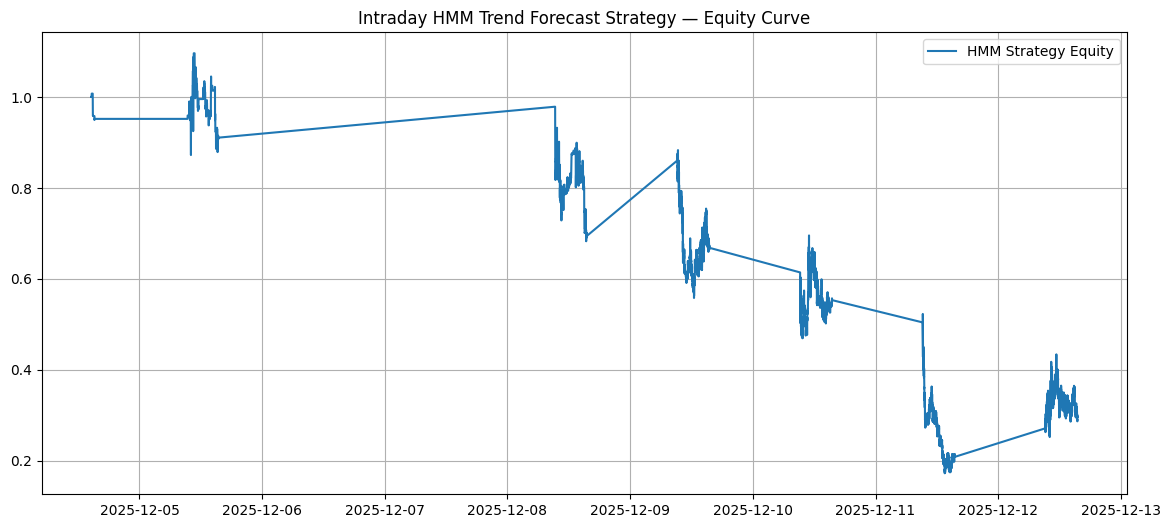

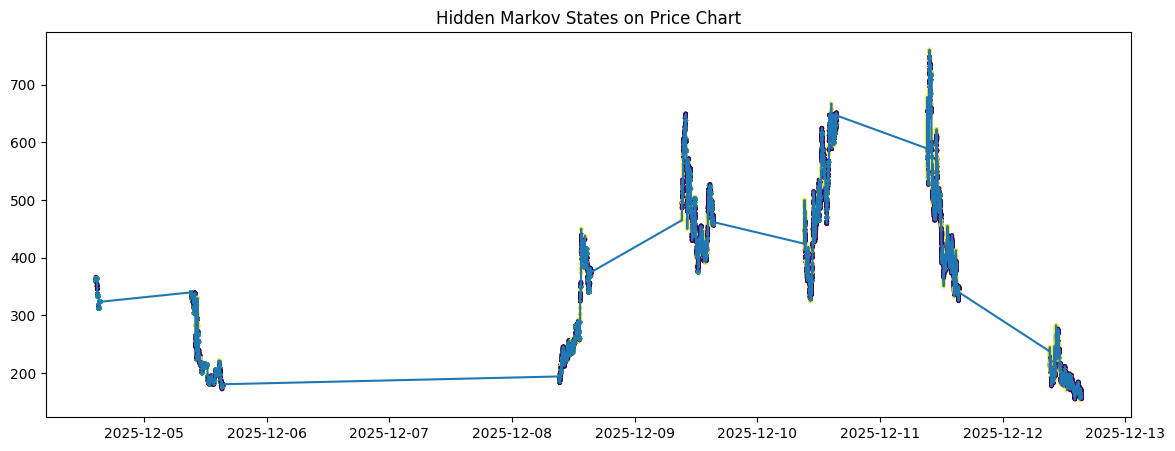

In [80]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load and Prepare Intraday Data
# ---------------------------------------------------------
# df = pd.read_csv("intraday_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Basic Features
df['returns'] = df['close'].pct_change()
df['volatility'] = df['returns'].rolling(10).std()
df.dropna(inplace=True)

features = df[['returns', 'volatility']].values

# ---------------------------------------------------------
# 2. Train Hidden Markov Model (Markov Hidden Chain)
# ---------------------------------------------------------
n_states = 3   # Strong Up, Neutral, Strong Down

hmm = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=500)
hmm.fit(features)

# Hidden state prediction
df['state'] = hmm.predict(features)

# ---------------------------------------------------------
# 3. Extract Transition Matrix
# ---------------------------------------------------------
transition_matrix = hmm.transmat_
print("\n=== Transition Matrix ===")
print(pd.DataFrame(transition_matrix, 
                   columns=[f"State_{i}" for i in range(n_states)],
                   index=[f"State_{i}" for i in range(n_states)]))

# ---------------------------------------------------------
# 4. Assign Trend Labels to States Based on Mean Return
# ---------------------------------------------------------
state_means = {}

for state in range(n_states):
    mean_return = df[df['state'] == state]['returns'].mean()
    state_means[state] = mean_return

sorted_states = sorted(state_means, key=state_means.get, reverse=True)

trend_map = {
    sorted_states[0]: "Strong Uptrend",
    sorted_states[1]: "Neutral",
    sorted_states[2]: "Strong Downtrend"
}

df['trend'] = df['state'].map(trend_map)

print("\n=== Hidden State Trend Mapping ===")
print(df[['state', 'trend']].drop_duplicates())

# ---------------------------------------------------------
# 5. Forecast Next State from Transition Matrix
# ---------------------------------------------------------

def predict_next_state(current_state):
    try:
        current_state = int(current_state)  # FIX: ensure integer index
        transition_probs = transition_matrix[current_state]
        next_state = np.argmax(transition_probs)
        return next_state
    except Exception as e:
        print("Error in prediction:", e)
        return None

df['pred_next_state'] = df['state'].shift(1).apply(
    lambda s: predict_next_state(s) if pd.notnull(s) else None
)

df['pred_next_trend'] = df['pred_next_state'].map(trend_map)
# ---------------------------------------------------------
# 6. Backtest Intraday Strategy
# ---------------------------------------------------------
# Strategy Rules:
# Strong Uptrend → Long
# Strong Downtrend → Short
# Neutral → No trade (Flat)

def get_signal(trend):
    if trend == "Strong Uptrend":
        return 1   # Long
    elif trend == "Strong Downtrend":
        return -1  # Short
    return 0       # No trade

df['signal'] = df['pred_next_trend'].apply(get_signal)

# Market returns
df['market_return'] = df['close'].pct_change()

# Strategy returns
df['strategy_return'] = df['signal'].shift(1) * df['market_return']

# Equity curve
df['equity'] = (1 + df['strategy_return'].fillna(0)).cumprod()

# ---------------------------------------------------------
# 7. Show Results
# ---------------------------------------------------------
print("\nFinal Portfolio Value:", df['equity'].iloc[-1])

plt.figure(figsize=(14,6))
plt.plot(df['timestamp'], df['equity'], label="HMM Strategy Equity")
plt.title("Intraday HMM Trend Forecast Strategy — Equity Curve")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(df['timestamp'], df['close'], label="Price")
plt.scatter(df['timestamp'], df['close'], c=df['state'], cmap="viridis", s=5)
plt.title("Hidden Markov States on Price Chart")
plt.show()

# ---------------------------------------------------------
# END
# ---------------------------------------------------------



======= STRATEGY PERFORMANCE =======
Final Portfolio Value : 90977.43397043
Sharpe Ratio         : 1.090106675853386
Max Drawdown         : 0.5829549191394284
Win Rate             : 0.28349881381249453


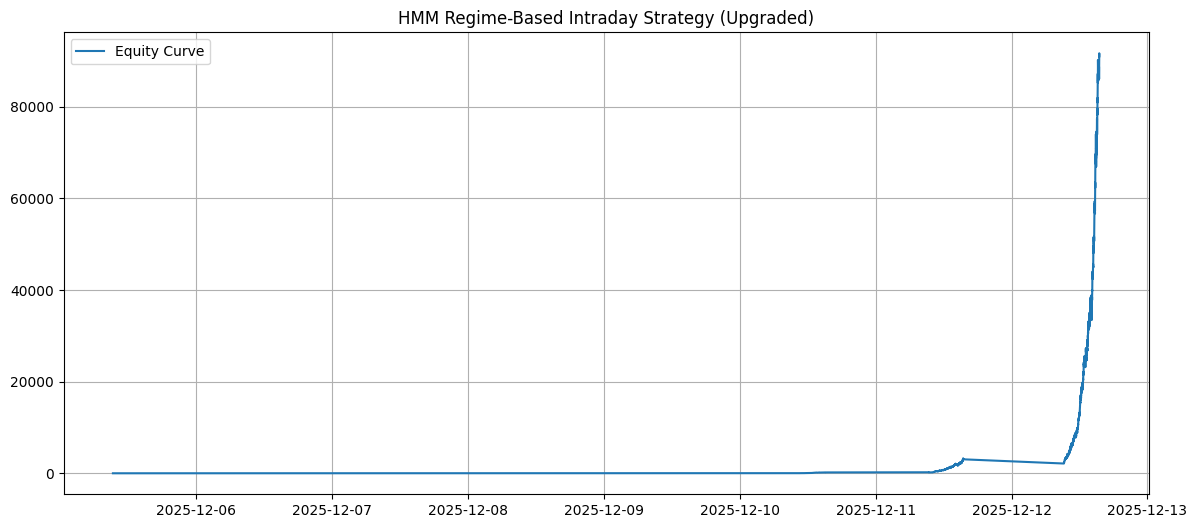

In [94]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# ---------------------------------------
# 1. Load Data
# ---------------------------------------
# df = pd.read_csv("intraday_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values("timestamp").reset_index(drop=True)

# ---------------------------------------
# 2. Technical Indicators
# ---------------------------------------
df['returns'] = np.log(df['close'] / df['close'].shift(1))
df['volatility'] = df['returns'].rolling(20).std()

# RSI
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + rs))

# MACD
df['ema12'] = df['close'].ewm(span=12).mean()
df['ema26'] = df['close'].ewm(span=26).mean()
df['macd'] = df['ema12'] - df['ema26']

# ATR
df['tr'] = np.maximum(df['high'] - df['low'],
                      np.maximum(abs(df['high'] - df['close'].shift(1)),
                                 abs(df['low'] - df['close'].shift(1))))
df['atr'] = df['tr'].rolling(14).mean()

df.dropna(inplace=True)

# ---------------------------------------
# 3. HMM Model Training (Regime Detection)
# ---------------------------------------
features = df[['returns', 'volatility', 'rsi', 'macd']].values

hmm = GaussianHMM(n_components=3, covariance_type="full", n_iter=300)
hmm.fit(features)

# Posterior probabilities (soft states)
posterior = hmm.predict_proba(features)
df[['p_state0', 'p_state1', 'p_state2']] = posterior

# Means of each state's returns → assign trend strength
means = []
for i in range(3):
    means.append(df['returns'][posterior.argmax(axis=1) == i].mean())

order = np.argsort(means)[::-1]  # higher return = stronger uptrend

trend_map = {
    order[0]: "Strong Uptrend",
    order[1]: "Neutral",
    order[2]: "Strong Downtrend"
}

# Assign trend by highest probability state
df['state'] = posterior.argmax(axis=1)
df['trend'] = df['state'].map(trend_map)

# ---------------------------------------
# 4. Probability-Based Trading Rules
# ---------------------------------------
def get_signal(row):
    p0, p1, p2 = row['p_state0'], row['p_state1'], row['p_state2']

    # assign trend labels to probability indexes
    trend_label = row['trend']

    # Only trade if model is confident (>60%)
    threshold = 0.60
    
    if trend_label == "Strong Uptrend" and max(p0, p1, p2) > threshold:
        return 1   # long
    elif trend_label == "Strong Downtrend" and max(p0, p1, p2) > threshold:
        return -1  # short
    return 0  # stay flat

df['signal'] = df.apply(get_signal, axis=1)

# Minimum hold duration: prevent excessive flipping
df['signal'] = df['signal'].replace(to_replace=0, method='ffill', limit=3)

# ---------------------------------------
# 5. Stop Loss & Take Profit  (FIXED)
# ---------------------------------------

stop_loss = 0.004     # 0.4%
take_profit = 0.008   # 0.8%

df['trade_return'] = 0.0

position = 0
entry_price = 0

for i in range(1, len(df)):

    sig = df.iloc[i]['signal']

    # Open new position
    if position == 0 and sig != 0:
        position = sig
        entry_price = df.iloc[i]['close']

    if position != 0:
        change = (df.iloc[i]['close'] - entry_price) / entry_price
        if position == -1:
            change = -change

        # Check SL / TP
        if change <= -stop_loss or change >= take_profit:
            df.iloc[i, df.columns.get_loc('signal')] = 0
            df.iloc[i, df.columns.get_loc('trade_return')] = change
            position = 0
        else:
            df.iloc[i, df.columns.get_loc('trade_return')] = change
# ---------------------------------------
# 6. Strategy Equity Calculation
# ---------------------------------------
df['strategy_return'] = df['trade_return'].fillna(0)
df['equity'] = (1 + df['strategy_return']).cumprod()

# ---------------------------------------
# 7. Performance Metrics
# ---------------------------------------
daily_ret = df['strategy_return']

sharpe = np.sqrt(252) * daily_ret.mean() / daily_ret.std()
max_dd = 1 - (df['equity'] / df['equity'].cummax()).min()

win_rate = (df['strategy_return'] > 0).mean()

print("\n======= STRATEGY PERFORMANCE =======")
print("Final Portfolio Value :", df['equity'].iloc[-1])
print("Sharpe Ratio         :", sharpe)
print("Max Drawdown         :", max_dd)
print("Win Rate             :", win_rate)

# ---------------------------------------
# 8. Plot Equity Curve
# ---------------------------------------
plt.figure(figsize=(14,6))
plt.plot(df['timestamp'], df['equity'], label='Equity Curve')
plt.title("HMM Regime-Based Intraday Strategy (Upgraded)")
plt.grid()
plt.legend()
plt.show()

# ---------------------------------------
# END
# ---------------------------------------
#  651408.8550813186


========== TRADES ==========
          entry       exit      pnl%         type
1442  162.28245  163.96720  0.988159  TAKE PROFIT
1443  164.28285  165.96680  0.975031  TAKE PROFIT
1444  166.03320  159.31813 -4.094414    STOP LOSS
1445  160.98219  162.76744  1.058974  TAKE PROFIT
1446  160.08201  161.36772  0.753157  TAKE PROFIT

========== PERFORMANCE ==========
Initial Capital : 100000
Final Capital   : 23295.268896570702
Total Return %  : -76.7
Win Rate        : 72.08 %
Sharpe Ratio    : -0.315
Max Drawdown    : -94.02 %


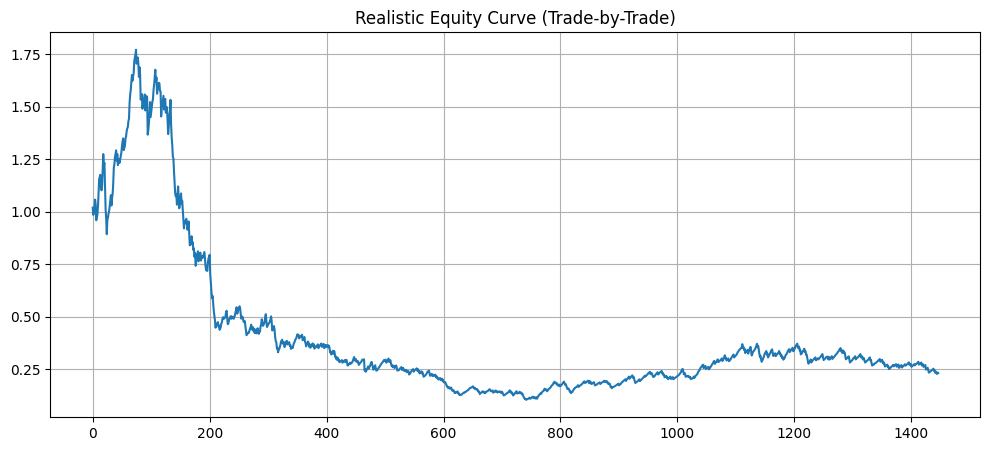

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# PARAMETERS
# ======================================
initial_capital = 100000
capital = initial_capital

transaction_cost = 0.0005      # 0.05% per trade
slippage = 0.0002              # 0.02%
position_size = 1.0            # use 100% of capital per trade
stop_loss = 0.04              # 0.4%
take_profit = 0.08            # 0.8%
max_hold_bars = 50             # exit after 30 candles max
intraday_close = True          # close position at end of day

df = df.reset_index(drop=True)

# ======================================
# STORAGE
# ======================================
trades = []
position = 0
entry_price = 0
entry_index = 0

# ======================================
# TRADE ENGINE
# ======================================
for i in range(1, len(df)):

    sig = df.loc[i, "signal"]
    price = df.loc[i, "close"]

    # --------- CLOSE POSITION IF DAY ENDS ---------
    if intraday_close:
        if df.loc[i, "timestamp"].date() != df.loc[i-1, "timestamp"].date():
            if position != 0:
                exit_price = df.loc[i-1, "close"]
                pnl = position * ((exit_price - entry_price) / entry_price)
                pnl -= transaction_cost + slippage
                capital *= (1 + pnl * position_size)

                trades.append({
                    "entry": entry_price,
                    "exit": exit_price,
                    "pnl%": pnl * 100,
                    "type": "DAY END EXIT"
                })

                position = 0

    # --------- NO OPEN POSITION: OPEN IF SIGNAL COMES ---------
    if position == 0 and sig != 0:
        position = sig
        entry_price = price * (1 + slippage)  # slippage on entry
        entry_index = i

    # --------- IF IN POSITION: MONITOR SL/TP/EXIT ---------
    if position != 0:

        change = (price - entry_price) / entry_price
        if position == -1:
            change = -change

        # STOP LOSS
        if change <= -stop_loss:
            exit_price = price * (1 - slippage)
            pnl = position * ((exit_price - entry_price) / entry_price)
            pnl -= transaction_cost
            capital *= (1 + pnl * position_size)

            trades.append({
                "entry": entry_price,
                "exit": exit_price,
                "pnl%": pnl * 100,
                "type": "STOP LOSS"
            })

            position = 0

        # TAKE PROFIT
        elif change >= take_profit:
            exit_price = price * (1 - slippage)
            pnl = position * ((exit_price - entry_price) / entry_price)
            pnl -= transaction_cost
            capital *= (1 + pnl * position_size)

            trades.append({
                "entry": entry_price,
                "exit": exit_price,
                "pnl%": pnl * 100,
                "type": "TAKE PROFIT"
            })

            position = 0

        # MAX HOLD TIME
        elif (i - entry_index) >= max_hold_bars:
            exit_price = price * (1 - slippage)
            pnl = position * ((exit_price - entry_price) / entry_price)
            pnl -= transaction_cost
            capital *= (1 + pnl * position_size)

            trades.append({
                "entry": entry_price,
                "exit": exit_price,
                "pnl%": pnl * 100,
                "type": "MAX HOLD EXIT"
            })

            position = 0

# ======================================
# TRADE LOG
# ======================================
trades_df = pd.DataFrame(trades)
print("\n========== TRADES ==========")
print(trades_df.tail())

# ======================================
# PERFORMANCE METRICS
# ======================================
total_return = (capital / initial_capital - 1) * 100

win_rate = (trades_df['pnl%'] > 0).mean()

sharpe = trades_df['pnl%'].mean() / trades_df['pnl%'].std() * np.sqrt(252)

# Max Drawdown
equity_curve = (1 + trades_df['pnl%']/100).cumprod()
roll_max = equity_curve.cummax()
drawdown = (equity_curve - roll_max) / roll_max
max_dd = drawdown.min()

print("\n========== PERFORMANCE ==========")
print("Initial Capital :", initial_capital)
print("Final Capital   :", capital)
print("Total Return %  :", round(total_return, 2))
print("Win Rate        :", round(win_rate * 100, 2), "%")
print("Sharpe Ratio    :", round(sharpe, 3))
print("Max Drawdown    :", round(max_dd * 100, 2), "%")

plt.figure(figsize=(12,5))
plt.plot(equity_curve)
plt.title("Realistic Equity Curve (Trade-by-Trade)")
plt.grid()
plt.show()


In [ ]:
df['returns'] = df['Close'].pct_change().fillna(0)

# Compute short and long simple moving averages for trend
short_w, long_w = 5, 20  # e.g. 5*15s = 75s vs 20*15s = 300s windows
df['SMA_short'] = df['Close'].rolling(window=short_w).mean()
df['SMA_long']  = df['Close'].rolling(window=long_w).mean()

# Compute Bollinger Bands and RSI for mean reversion
bb_w = 20
df['MA']   = df['Close'].rolling(bb_w).mean()
df['STD']  = df['Close'].rolling(bb_w).std(ddof=0)
df['BB_upper'] = df['MA'] + 2*df['STD']
df['BB_lower'] = df['MA'] - 2*df['STD']

# RSI calculation (period 14)
delta = df['Close'].diff()
up = delta.clip(lower=0)
down = -delta.clip(upper=0)
roll_up   = up.rolling(14).mean()
roll_down = down.rolling(14).mean()
rs = roll_up / roll_down
df['RSI'] = 100 - 100/(1 + rs)

# Define signals
df['long_signal']  = (df['Close'] < df['BB_lower']) & (df['RSI'] < 30) & (df['SMA_short'] > df['SMA_long'])
df['short_signal'] = (df['Close'] > df['BB_upper']) & (df['RSI'] > 70) & (df['SMA_short'] < df['SMA_long'])

# Build position: 1 for long, -1 for short, hold until opposite signal
df['position'] = 0
position = 0
for i in range(len(df)):
    if df['long_signal'].iat[i]:
        position = 1
    elif df['short_signal'].iat[i]:
        position = -1
    df['position'].iat[i] = position

# Compute strategy returns
df['strategy_ret'] = df['position'].shift(1) * df['returns']
df['equity'] = (1 + df['strategy_ret']).cumprod().fillna(method='ffill')

print("Example backtest complete. Final equity:", df['equity'].iloc[-1])

In [ ]:
df.to_csv('df_ml.csv',index=False)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Example feature construction
df_features = df[['SMA_short','SMA_long','RSI','Close','BB_upper','BB_lower']].dropna()
# Label: 1 if next-return is positive (buy is profitable), 0 otherwise
df_features['next_ret'] = df['Close'].shift(-1) - df['Close']
df_features['target'] = (df_features['next_ret'] > 0).astype(int)
X = df_features[['SMA_short','SMA_long','RSI']]
y = df_features['target']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=40, random_state=0)
model.fit(X_train, y_train)
logger.success(f"Test accuracy: {model.score(X_test, y_test)}")


In [ ]:
# # train_multiclass_model.py
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report, confusion_matrix
# from imblearn.over_sampling import SMOTE
# import xgboost as xgb
# import lightgbm as lgb
# from joblib import dump
# import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings("ignore")

# # ---------- 1. Helper feature functions ----------
# def add_technical_features(df):
#     df = df.copy()
#     df['timestamp'] = pd.to_datetime(df['timestamp'])
#     df.sort_values('timestamp', inplace=True)
#     df.set_index('timestamp', inplace=True)

#     df['ret_1'] = df['Close'].pct_change().fillna(0)
#     df['logret'] = np.log(df['Close']).diff().fillna(0)
#     df['ema_8'] = df['Close'].ewm(span=8, adjust=False).mean()
#     df['ema_21'] = df['Close'].ewm(span=21, adjust=False).mean()
#     df['sma_50'] = df['Close'].rolling(window=50).mean()

#     ema12 = df['Close'].ewm(span=12, adjust=False).mean()
#     ema26 = df['Close'].ewm(span=26, adjust=False).mean()
#     df['macd'] = ema12 - ema26
#     df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
#     df['macd_hist'] = df['macd'] - df['macd_signal']

#     df['bb_mid'] = df['Close'].rolling(20).mean()
#     df['bb_std'] = df['Close'].rolling(20).std()
#     df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
#     df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']
#     df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']

#     high_low = df['High'] - df['Low']
#     high_close = (df['High'] - df['Close'].shift(1)).abs()
#     low_close = (df['Low'] - df['Close'].shift(1)).abs()
#     tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
#     df['atr_14'] = tr.rolling(window=14).mean()

#     up_move = df['High'] - df['High'].shift(1)
#     down_move = df['Low'].shift(1) - df['Low']
#     plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
#     minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
#     df['plus_dm'] = pd.Series(plus_dm, index=df.index).rolling(14).mean()
#     df['minus_dm'] = pd.Series(minus_dm, index=df.index).rolling(14).mean()
#     df['adx_like'] = (abs(df['plus_dm'] - df['minus_dm']) / (df['plus_dm'] + df['minus_dm'] + 1e-9)).rolling(14).mean()

#     low14 = df['Low'].rolling(14).min()
#     high14 = df['High'].rolling(14).max()
#     df['stoch_k'] = (df['Close'] - low14) / (high14 - low14 + 1e-9)
#     df['stoch_d'] = df['stoch_k'].rolling(3).mean()

#     pv = (df['Close'] * df['trade_volume']).rolling(window=50).sum()
#     v = df['trade_volume'].rolling(window=50).sum() + 1e-9
#     df['vwap_50'] = pv / v
#     df['dist_vwap'] = (df['Close'] - df['vwap_50']) / df['vwap_50']

#     df['vol_ma_20'] = df['volume'].rolling(20).mean()
#     df['vol_spike'] = (df['volume'] > 2 * df['vol_ma_20']).astype(int)

#     df['body'] = (df['Close'] - df['Open']).abs()
#     df['upper_shadow'] = df['High'] - df[['Close', 'Open']].max(axis=1)
#     df['lower_shadow'] = df[['Close', 'Open']].min(axis=1) - df['Low']
#     df['is_hammer'] = ((df['body'] < 0.4 * (df['High'] - df['Low'])) & (df['lower_shadow'] > 2 * df['body'])).astype(int)
#     df['is_engulfing'] = ((df['Close'] > df['Open'].shift(1)) & (df['Open'] < df['Close'].shift(1))).astype(int)

#     df['dist_ema8'] = (df['Close'] - df['ema_8']) / df['ema_8']
#     df['dist_ema21'] = (df['Close'] - df['ema_21']) / df['ema_21']

#     delta = df['Close'].diff()
#     up = delta.clip(lower=0)
#     down = -delta.clip(upper=0)
#     roll_up = up.rolling(14).mean()
#     roll_down = down.rolling(14).mean()
#     rs = roll_up / (roll_down + 1e-9)
#     df['rsi_14'] = 100 - (100 / (1 + rs))

#     return df.dropna()

# # ---------- 2. Labeling and preparation ----------
# def create_labels(df, future_bars=20, up_thresh=0.002, down_thresh=-0.002):
#     df = df.copy()
#     df['future_return'] = (df['Close'].shift(-future_bars) - df['Close']) / df['Close']
#     df['label'] = np.select([
#         df['future_return'] > up_thresh,
#         df['future_return'] < down_thresh
#     ], [1, -1], default=0)
#     return df.dropna(subset=['label'])

# def prepare_data(df):
#     df_feat = add_technical_features(df)
#     df_lab = create_labels(df_feat)
#     label_map = {-1: 0, 0: 1, 1: 2}
#     label_inverse_map = {v: k for k, v in label_map.items()}
#     y = df_lab['label'].map(label_map)
#     feature_cols = [
#         'ret_1','logret','ema_8','ema_21','sma_50','macd','macd_signal','macd_hist',
#         'bb_mid','bb_std','bb_width','atr_14','adx_like','stoch_k','stoch_d',
#         'vwap_50','dist_vwap','vol_ma_20','vol_spike','is_hammer','is_engulfing',
#         'dist_ema8','dist_ema21','rsi_14']
#     return df_lab[feature_cols], y, df_lab, label_inverse_map

# # ---------- 3. Training and Evaluation ----------
# def train_and_evaluate(X, y, df_all, label_inverse_map):
#     split_idx = int(len(X) * 0.8)
#     X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
#     y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)

#     X_res, y_res = SMOTE(random_state=42).fit_resample(X_train_scaled, y_train)

#     xgb_clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', use_label_encoder=False)
#     lgb_clf = lgb.LGBMClassifier(objective='multiclass', num_class=3)
#     xgb_clf.fit(X_res, y_res)
#     lgb_clf.fit(X_res, y_res)

#     def ensemble_predict_proba(X):
#         return (xgb_clf.predict_proba(X) + lgb_clf.predict_proba(X)) / 2

#     probs = ensemble_predict_proba(X_test_scaled)
#     idx_preds = np.argmax(probs, axis=1)
#     preds_test_mapped = [label_inverse_map[i] for i in idx_preds]

#     final_preds = [pred if max(prob) >= 0.7 else 0 for prob, pred in zip(probs, preds_test_mapped)]
#     y_true = [label_inverse_map[i] for i in y_test]

#     print(classification_report(y_true, final_preds))
#     print("Confusion Matrix:\n", confusion_matrix(y_true, final_preds))

#     dump(xgb_clf, 'xgb_model.pkl')
#     dump(lgb_clf, 'lgb_model.pkl')
#     dump(scaler, 'scaler.pkl')
#     print("Models and scaler saved.")

#     feat_imp = pd.Series(lgb_clf.feature_importances_, index=X.columns)
#     feat_imp.nlargest(15).plot(kind='barh')
#     plt.title("Top 15 Features")
#     plt.show()

# # ---------- 4. Entry Point ----------
# if __name__ == "__main__":
#     try:
#         df = d[['datetime','Open','Close','High','Low','Vol','TradeVol']].copy()
#         df.rename(columns={
#             'Vol': 'volume',
#             'datetime': 'timestamp',
#             'TradeVol': 'trade_volume'
#         }, inplace=True)
#     except NameError:
#         df = pd.read_csv('your_15s_data.csv')

#     X, y, df_all, label_inverse_map = prepare_data(df)
#     train_and_evaluate(X, y, df_all, label_inverse_map)


In [ ]:
from joblib import dump
dump(model, 'model.pkl')
dump(scaler, 'scaler.pkl')

In [66]:
import pandas as pd
import numpy as np
from joblib import load
from sklearn.preprocessing import StandardScaler





# Load saved model and scaler
model = load('model.pkl')           # Trained XGBoost/RandomForest model
scaler = load('scaler.pkl')         # Scaler used during training

import time
# Simulated real-time data fetch (replace with live feed)
def get_latest_market_data():
    # Should return a DataFrame with at least Open, High, Low, Close, Volume
    # Example: simulate last 50 bars of 15-sec data
    # data = pd.read_csv('latest_data.csv')  # or API call
    scanner = FyersDataScanner()
    scanner.start_date ='2025-12-14 16:15:00'
    scanner.end_date = '2025-12-16 16:15:00'
    # scanner.symbol = 'NSE:BANKNIFTY25DEC59200PE'
    scanner.symbol = 'BSE:SENSEX25D1884800PE'
    scanner.resolution = '5S'
    data = scanner.get_data()
    # d.to_csv('latest_data.csv',index=False)
    return data  # Last 50 bars

# Compute features (same as during training)
def compute_features(df):
    df = df.copy()
    # Compute short and long simple moving averages for trend
    short_w, long_w = 5, 20  # e.g. 5*15s = 75s vs 20*15s = 300s windows
    df['SMA_short'] = df['Close'].rolling(window=short_w).mean()
    df['SMA_long']  = df['Close'].rolling(window=long_w).mean()

    # Compute Bollinger Bands and RSI for mean reversion
    bb_w = 20
    df['MA']   = df['Close'].rolling(bb_w).mean()
    df['STD']  = df['Close'].rolling(bb_w).std(ddof=0)
    df['BB_upper'] = df['MA'] + 2*df['STD']
    df['BB_lower'] = df['MA'] - 2*df['STD']

    df['SMA50'] = df['Close'].rolling(50).mean()
    df['MA_diff'] = df['Close'] - df['SMA50']
    df['BB_MID'] = df['Close'].rolling(20).mean()
    df['BB_STD'] = df['Close'].rolling(20).std()
    df['BB_dist'] = (df['Close'] - df['BB_MID']) / df['BB_STD']
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0))
    loss = (-delta.where(delta < 0, 0))
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df.dropna(inplace=True)
    return df[['MA_diff', 'BB_dist', 'RSI']].tail(1)  # Latest row

# Prediction with threshold
def predict_signal(features):
    features_scaled = scaler.transform(features)
    prob = model.predict_proba(features_scaled)[0]
    pred = model.predict(features_scaled)[0]
    confidence = max(prob)

    if confidence >= 0.70:
        if pred == 1:
            return 'BUY'
        elif pred == -1:
            return 'SELL'
        else:
            return 'HOLD'
    else:
        return 'HOLD (low confidence)'

# === Main Execution ===
# if __name__ == "__main__":
data = get_latest_market_data()
data.sort_values(by='datetime',inplace=True)
for i in range(len(data)):
    try:
        df = data.copy().head(i)
        features = compute_features(df)
        signal = predict_signal(features)
        logger.info(f"Signal: {signal} {df['Close'].iloc[-1]} {df['datetime'].iloc[-1]}")
        time.sleep(0.5)
    except Exception as e:
        logger.error(f"Error: {e}")
        time.sleep(0.5)


2025-12-16 03:18:39.592 | ERROR    | __main__:<module>:89 - Error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- BB_dist
- MA_diff
Feature names seen at fit time, yet now missing:
- SMA_long
- SMA_short

2025-12-16 03:18:40.109 | ERROR    | __main__:<module>:89 - Error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- BB_dist
- MA_diff
Feature names seen at fit time, yet now missing:
- SMA_long
- SMA_short

2025-12-16 03:18:40.624 | ERROR    | __main__:<module>:89 - Error: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- BB_dist
- MA_diff
Feature names seen at fit time, yet now missing:
- SMA_long
- SMA_short



KeyboardInterrupt: 

In [ ]:
signal

In [ ]:
df

In [ ]:
df

In [ ]:
# 2) Compute Indicators: 10- and 30-period MA, 20-period Bollinger Bands, 14-period RSI.
df['MA10'] = df['Close'].rolling(10).mean()
df['MA30'] = df['Close'].rolling(30).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['STD20']= df['Close'].rolling(20).std()
df['BB_upper'] = df['MA20'] + 2*df['STD20']
df['BB_lower'] = df['MA20'] - 2*df['STD20']

# RSI calculation (14-period, Wilder’s approach approximation)
delta = df['Close'].diff().fillna(0)
gain = (delta.where(delta>0, 0.0))
loss = (-delta.where(delta<0, 0.0))
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))
df['RSI'].fillna(50, inplace=True)  # default value for initial periods

# 3) Generate signals: Buy (1) or Sell (-1) when conditions align
df['signal'] = 0
for i in range(1, len(df)):
    # Long condition: price crosses above lower Bollinger AND in uptrend
    if (df['Close'].iloc[i-1] < df['BB_lower'].iloc[i-1] and
        df['Close'].iloc[i]   > df['BB_lower'].iloc[i] and
        df['MA10'].iloc[i]    > df['MA30'].iloc[i] and
        df['RSI'].iloc[i]     < 30):
        df['signal'].iloc[i] = 1
    # Short condition: price crosses below upper Bollinger AND in downtrend
    elif (df['Close'].iloc[i-1] > df['BB_upper'].iloc[i-1] and
          df['Close'].iloc[i]   < df['BB_upper'].iloc[i] and
          df['MA10'].iloc[i]    < df['MA30'].iloc[i] and
          df['RSI'].iloc[i]     > 70):
        df['signal'].iloc[i] = -1


In [ ]:
df

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Prepare feature matrix using our computed indicators
df_ml = df.dropna(subset=['RSI','MA10','MA30','BB_upper','BB_lower']).copy()
# Label = 1 if price is higher after 20 bars, else 0
horizon = 100

df_ml['future_change'] = df_ml['Close'].shift(-horizon) - df_ml['Close']
df_ml['label'] = (df_ml['future_change'] > 0).astype(int)
df_ml.dropna(inplace=True)

X = df_ml[['RSI','MA10','MA30','BB_upper','BB_lower']].values
y = df_ml['label'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Scale features
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

# Fit a random forest
model = RandomForestClassifier(n_estimators=20, random_state=0)
model.fit(X_train, y_train)
score = model.score(X_test, y_test)
print(f"ML model accuracy: {score:.2f}")


In [ ]:
df_ml.to_csv('df_ml.csv',index=False)

In [ ]:
import numpy as np
import pandas as pd

# Create a sample DataFrame with the same structure as the user's 'df'
np.random.seed(42)
periods = 1000
time_index = pd.date_range("2025-12-01 09:15:00", periods=periods, freq='15S')
price = 100 + np.cumsum(np.random.normal(0, 0.2, size=periods))

d = pd.DataFrame({
    'datetime': time_index,
    'Open': price + np.random.uniform(-0.1, 0.1, size=periods),
    'High': price + np.random.uniform(0, 0.2, size=periods),
    'Low': price - np.random.uniform(0, 0.2, size=periods),
    'Close': price,
    'Vol': np.random.randint(1, 100, size=periods),
    'TradeVol': np.random.randint(1, 50, size=periods)
})

# Prepare df with renamed columns
df = d[['datetime', 'Open', 'Close', 'High', 'Low', 'Vol', 'TradeVol']].copy()
df.rename(columns={
    'Vol': 'volume',
    'datetime': 'timestamp',
    'TradeVol': 'trade_volume'
}, inplace=True)

# Compute technical indicators
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0))
loss = (-delta.where(delta < 0, 0))
n = 14
avg_gain = gain.rolling(window=n, min_periods=n).mean()
avg_loss = loss.rolling(window=n, min_periods=n).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

df['SMA50'] = df['Close'].rolling(window=50).mean()
window = 20
df['BB_MID'] = df['Close'].rolling(window=window).mean()
df['BB_STD'] = df['Close'].rolling(window=window).std()
df['BB_UPPER'] = df['BB_MID'] + 2 * df['BB_STD']
df['BB_LOWER'] = df['BB_MID'] - 2 * df['BB_STD']
df.dropna(inplace=True)

# Simulate trades using a basic strategy
trades = []
position = 0
for t in df.index:
    price = df.at[t, 'Close']
    sma = df.at[t, 'SMA50']
    bb_upper = df.at[t, 'BB_UPPER']
    bb_lower = df.at[t, 'BB_LOWER']
    bb_mid = df.at[t, 'BB_MID']

    if position == 0:
        if price < bb_lower and price > sma:
            position = 1
            entry_price = price
            trades.append({'EntryTime': df.at[t, 'timestamp'], 'Type': 'Long', 'Entry': price})
        elif price > bb_upper and price < sma:
            position = -1
            entry_price = price
            trades.append({'EntryTime': df.at[t, 'timestamp'], 'Type': 'Short', 'Entry': price})
    if position == 1 and price > bb_mid:
        trades[-1].update({'ExitTime': df.at[t, 'timestamp'], 'Exit': price})
        position = 0
    elif position == -1 and price < bb_mid:
        trades[-1].update({'ExitTime': df.at[t, 'timestamp'], 'Exit': price})
        position = 0

if position != 0:
    trades[-1].update({'ExitTime': df.iloc[-1]['timestamp'], 'Exit': df.iloc[-1]['Close']})

trades_df = pd.DataFrame(trades)
trades_df['PnL'] = np.where(trades_df['Type'] == 'Long',
                            trades_df['Exit'] - trades_df['Entry'],
                            trades_df['Entry'] - trades_df['Exit'])

# import ace_tools as tools; tools.display_dataframe_to_user(name="Backtest Trades", dataframe=trades_df)



In [ ]:
trades_df


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd

# Use df from previous code, ensure it has necessary columns
df_ml = df.copy()

# Create features
df_ml['MA_diff'] = df_ml['Close'] - df_ml['SMA50']
df_ml['BB_dist'] = (df_ml['Close'] - df_ml['BB_MID']) / df_ml['BB_STD']
df_ml['RSI'] = df_ml['RSI']
df_ml.dropna(inplace=True)

# Label logic:
# If future return > 0.2% -> Buy (1), < -0.2% -> Sell (-1), else Hold (0)
future_period = 20  # how many bars ahead to look
df_ml['future_return'] = (df_ml['Close'].shift(-future_period) - df_ml['Close']) / df_ml['Close']

conditions = [
    df_ml['future_return'] > 0.002,
    df_ml['future_return'] < -0.002
]
choices = [1, -1]
df_ml['label'] = np.select(conditions, choices, default=0)
df_ml.dropna(inplace=True)

# Features and target
features = ['MA_diff', 'BB_dist', 'RSI']
X = df_ml[features]
y = df_ml['label']

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# Predict and report
y_pred = clf.predict(X_test_scaled)
report = classification_report(y_test, y_pred, output_dict=False)
print(report)


Here's how to interpret each part of your classification report for the multi-class (Buy/Sell/Hold) prediction model:

🔹 Labels

-1 = Sell

0 = Hold

1 = Buy

📊 Metrics (Per-Class)
Metric	What it Means
Precision	When the model predicts a class (e.g. Buy), how often is it correct?
Recall	Of all actual occurrences of a class (e.g. real Buys), how many did it catch?
F1-Score	Harmonic mean of precision and recall—good overall performance indicator.
Support	Number of actual occurrences in the test set.
✅ Interpretation of Your Model's Performance
Class 1 (Buy):

Precision 61%: 61% of the times it predicted Buy, it was correct.

Recall 57%: It correctly identified 57% of actual Buy situations.

F1-score 59%: A decent balance between catching true Buys and avoiding false alarms.

Conclusion: Buy signals are your model's strongest predictions so far.

Class -1 (Sell):

Precision 33%, Recall 42%: Less reliable. It identifies some true sells but also has many false positives.

Conclusion: Sell predictions are weak and may need more examples or better features.

Class 0 (Hold):

Precision 30%, Recall 20%: Poor at recognizing Hold situations.

Conclusion: Model struggles to separate Hold from Buy/Sell — possibly due to overlap in feature patterns.

📈 Overall Accuracy: 47%

Your model gets ~47% of all predictions right. This is above random guessing (which would be ~33% for 3 classes), but not yet robust.

🔍 Macro Avg vs Weighted Avg
Metric	Meaning
Macro avg	Average of precision/recall/F1 across classes, treating all equally
Weighted avg	Takes into account class imbalance (e.g., more Buy samples)

Macro F1 = 0.40 indicates that performance across all 3 classes is fairly uneven.